# [Workshop] Abductive Reasoning using Bayes Method

# 0. Installation

In [3]:
# !pip install scikit-learn

# 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB

# 2. Check Data

In [2]:
# Loading the dataset
# ASD_data = pd.read_csv('./data.csv')
ASD_data = pd.read_csv('./Toddler Autism dataset.csv')

# Print the first 5 rows of the dataframe.
print(ASD_data.head())

   Case_No  A1  A2  A3  A4  A5  A6  A7  A8  A9  A10  Age_Mons  Qchat-10-Score  \
0        1   0   0   0   0   0   0   1   1   0    1        28               3   
1        2   1   1   0   0   0   1   1   0   0    0        36               4   
2        3   1   0   0   0   0   0   1   1   0    1        36               4   
3        4   1   1   1   1   1   1   1   1   1    1        24              10   
4        5   1   1   0   1   1   1   1   1   1    1        20               9   

  Sex       Ethnicity Jaundice Family_mem_with_ASD Who completed the test  \
0   f  middle eastern      yes                  no          family member   
1   m  White European      yes                  no          family member   
2   m  middle eastern      yes                  no          family member   
3   m        Hispanic       no                  no          family member   
4   f  White European       no                 yes          family member   

  Class/ASD Traits   
0                No  
1     

In [3]:
# Replace special 
ASD_data.columns=ASD_data.columns.str.replace('-','_')
ASD_data.columns=ASD_data.columns.str.replace('/','_')
ASD_data.columns=ASD_data.columns.str.replace(' ','_')
print(ASD_data.head())

   Case_No  A1  A2  A3  A4  A5  A6  A7  A8  A9  A10  Age_Mons  Qchat_10_Score  \
0        1   0   0   0   0   0   0   1   1   0    1        28               3   
1        2   1   1   0   0   0   1   1   0   0    0        36               4   
2        3   1   0   0   0   0   0   1   1   0    1        36               4   
3        4   1   1   1   1   1   1   1   1   1    1        24              10   
4        5   1   1   0   1   1   1   1   1   1    1        20               9   

  Sex       Ethnicity Jaundice Family_mem_with_ASD Who_completed_the_test  \
0   f  middle eastern      yes                  no          family member   
1   m  White European      yes                  no          family member   
2   m  middle eastern      yes                  no          family member   
3   m        Hispanic       no                  no          family member   
4   f  White European       no                 yes          family member   

  Class_ASD_Traits_  
0                No  
1     

In [4]:
# observing the shape of the data
print(ASD_data.shape)

(1054, 19)


# 3. Data Preprocessing

## 3.1. Choose appropriate features 

In [5]:
Sex = pd.Categorical(pd.Categorical(ASD_data['Sex']).codes)
Ethnicity = pd.Categorical(pd.Categorical(ASD_data['Ethnicity']).codes)
Jaundice = pd.Categorical(pd.Categorical(ASD_data['Jaundice']).codes)
Family_mem_with_ASD = pd.Categorical(pd.Categorical(ASD_data['Family_mem_with_ASD']).codes)
Class_ASD_Traits_ = pd.Categorical(pd.Categorical(ASD_data['Class_ASD_Traits_']).codes)

ASD_data['Sex'] = Sex
ASD_data['Ethnicity'] = Ethnicity
ASD_data['Jaundice'] = Jaundice
ASD_data['Family_mem_with_ASD'] = Family_mem_with_ASD
ASD_data['Class_ASD_Traits_'] = Class_ASD_Traits_

# Check the data and think why we drop these variables?
X = ASD_data.drop(['Case_No', 'Who_completed_the_test', 'Qchat_10_Score', 'Class_ASD_Traits_', 'Age_Mons'], axis=1)
# X = ASD_data.drop(['Case_No', 'Who_completed_the_test', 'Class_ASD_Traits_'], axis=1)
X


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Sex,Ethnicity,Jaundice,Family_mem_with_ASD
0,0,0,0,0,0,0,1,1,0,1,0,8,1,0
1,1,1,0,0,0,1,1,0,0,0,1,5,1,0
2,1,0,0,0,0,0,1,1,0,1,1,8,1,0
3,1,1,1,1,1,1,1,1,1,1,1,0,0,0
4,1,1,0,1,1,1,1,1,1,1,0,5,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049,0,0,0,0,0,0,0,0,0,1,0,5,0,1
1050,0,0,1,1,1,0,1,0,1,0,1,7,1,0
1051,1,0,1,1,1,1,1,1,1,1,1,8,1,0
1052,1,0,0,0,0,0,0,1,0,1,1,5,0,1


## 3.2 Choose target

In [7]:
# Y_classification = ASD_data.Outcome
Y_classification = ASD_data.Class_ASD_Traits_

# 4. Build Naive Bayes Model

## 4.1 Split the dataset into training set and test set

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, Y_classification, test_size=1 / 5, random_state=1,
                                                    stratify=Y_classification)
print(X_train.shape)
print(X_test.shape)

(843, 14)
(211, 14)


## 4.2. Build Naive Bayes Model

In [9]:
NaiveBayesModel = MultinomialNB()
NaiveBayesModel.fit(X_train, y_train)

print('Score in training set: {:.3f}'.format(NaiveBayesModel.score(X_train, y_train)))
print('Score in test set: {:3f}'.format(NaiveBayesModel.score(X_test,y_test)))


Score in training set: 0.924
Score in test set: 0.928910


# 5. Visualize the Outcome

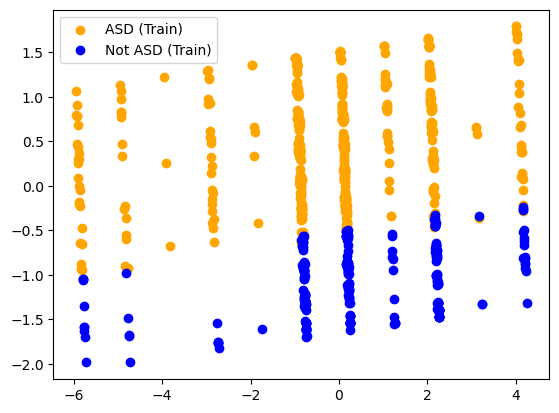

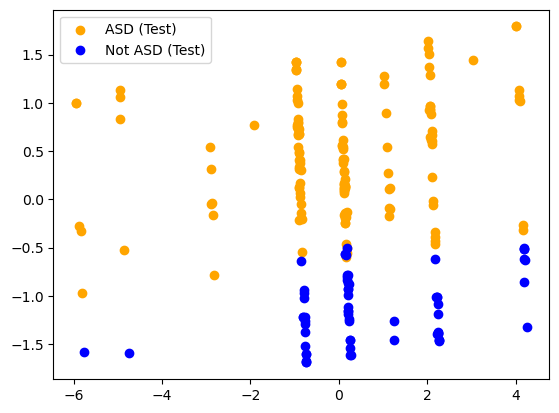

In [10]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_new = pca.fit_transform(np.concatenate((X_train,X_test)))

# Train set
plt.scatter(X_new[:843, 0][y_train==1], X_new[:843, 1][y_train==1], marker='o', c='orange') # Orange: ASD_in_train; 
plt.scatter(X_new[:843, 0][y_train==0], X_new[:843, 1][y_train==0], marker='o', c='b') # Blue Not ASD_in_train;
plt.legend(['ASD (Train)', 'Not ASD (Train)'])
plt.show()

# Test set
plt.scatter(X_new[843:, 0][y_test==1], X_new[843:, 1][y_test==1], marker='o', c='orange') # Orange: ASD_in_test; 
plt.scatter(X_new[843:, 0][y_test==0], X_new[843:, 1][y_test==0], marker='o', c='b') # Blue Not ASD_in_test;
plt.legend(['ASD (Test)', 'Not ASD (Test)'])
plt.show()

### Confusion matrix: TP; TN; FP; FN

https://en.wikipedia.org/wiki/Confusion_matrix


| Confusion Matrix  |   |  |  |
| :-: | :-: | :-: | :-: |
|  |  | Actual Class | Actual Class |
|  |  | **Positive** | **Negative** |
| Predicted Class | **Positive** | TP: True Positive | FP: False Positive |
| Predicted Class | **Negative** | FN: False Negative | TN: True Negative |


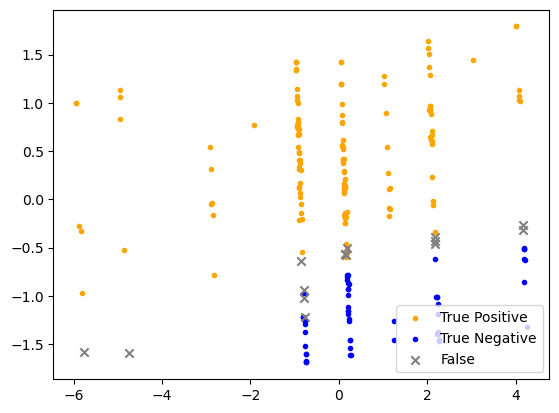

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Initialize empty Series to track each category
ASD_ASD = pd.Series(dtype='int')  # True Positive: y_test is ASD and recognized as ASD (Correct)
NOT_ASD_NOT_ASD = pd.Series(dtype='int')  # True Negative: y_test is NOT ASD and recognized as NOT ASD (Correct)
wrong_answer = pd.Series(dtype='int')  # False: y_test is ASD and recognized as NOT ASD  or y_test is NOT ASD and recognized as ASD (Wrong)

#get predictions
y_predict = NaiveBayesModel.predict(X_test)

# Iterate through ground truth and predicted labels
for y_gt, y_pd in zip(list(y_test), y_predict):
    if y_gt == 1 and y_pd == 1: # True Positive
        ASD_ASD = pd.concat([ASD_ASD, pd.Series([1])])
        NOT_ASD_NOT_ASD = pd.concat([NOT_ASD_NOT_ASD, pd.Series([0])])
        wrong_answer = pd.concat([wrong_answer, pd.Series([0])])
    elif y_gt == 0 and y_pd == 0: # True Negative
        ASD_ASD = pd.concat([ASD_ASD, pd.Series([0])])
        NOT_ASD_NOT_ASD = pd.concat([NOT_ASD_NOT_ASD, pd.Series([1])])
        wrong_answer = pd.concat([wrong_answer, pd.Series([0])])
    else: # Wrong prediction
        ASD_ASD = pd.concat([ASD_ASD, pd.Series([0])])
        NOT_ASD_NOT_ASD = pd.concat([NOT_ASD_NOT_ASD, pd.Series([0])])
        wrong_answer = pd.concat([wrong_answer, pd.Series([1])])
# can vectorize for faster:
# y_predict = NaiveBayesModel.predict(X_test)
#
# ASD_ASD = ((y_test == 1) & (y_predict == 1)).astype(int)
# NOT_ASD_NOT_ASD = ((y_test == 0) & (y_predict == 0)).astype(int)
# wrong_answer = (y_test != y_predict).astype(int)

# Plotting
plt.scatter(X_new[843:, 0][ASD_ASD == 1], X_new[843:, 1][ASD_ASD == 1], marker='.', c='orange')
plt.scatter(X_new[843:, 0][NOT_ASD_NOT_ASD == 1], X_new[843:, 1][NOT_ASD_NOT_ASD == 1], marker='.', c='blue')
plt.scatter(X_new[843:, 0][wrong_answer == 1], X_new[843:, 1][wrong_answer == 1], marker='x', c='grey')

plt.legend(['True Positive', 'True Negative', 'False'], loc='lower right')
plt.show()


### Quiz: What you observe from the above figure? Where do wrong predicitons mostly like to occur?
* Scatter plot:
    * Orange: correct ASD
    * blue: correct NOT-ASD
    * crosses: misclassificiations
    * gray X's are mostly clustered aroudn the decisoin boudnary region
* NB is getting confused where feature values of the classes overlap, where feature distributions are nearby and both class likelihood are trying to dominate
* since NB assumes feature independence, feature that are continuous, standardized, or have negatives may not be modelled well
* to improve, we try gaussian NB, feature scaling, and better visualisation

In [25]:
# Your answer and reasoning:
#
#
#

In [27]:
# Your code:
#
#
#

In [12]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X_train, y_train)
y_predict = model.predict(X_test)

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

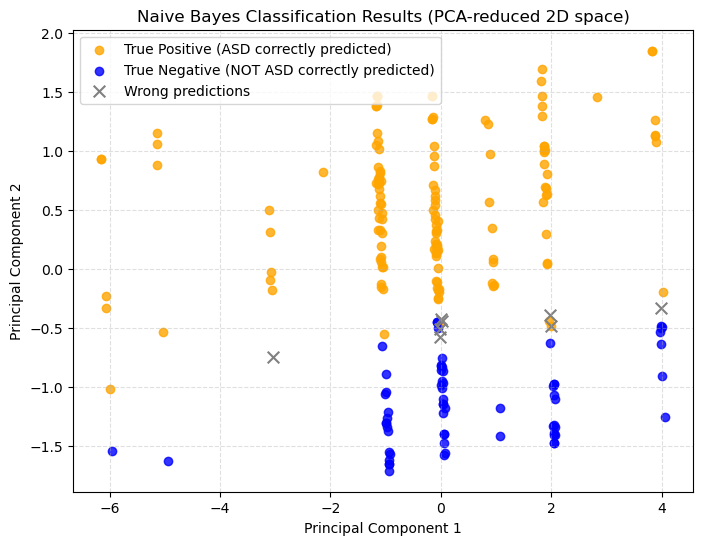

In [18]:
# --- Import required libraries ---
# from sklearn.decomposition import PCA        # for dimensionality reduction
# import matplotlib.pyplot as plt              # for plotting

# --- Step 1: Reduce high-dimensional test data (14 features) to 2D using PCA ---
pca = PCA(n_components=2)                    # create PCA transformer that keeps 2 principal components
X_test_2d = pca.fit_transform(X_test)        # project X_test onto 2D space

# --- Step 2: Identify which samples were classified correctly or wrongly ---
wrong = y_predict != y_test                  # Boolean mask: True where prediction != ground truth
correct = y_predict == y_test                # Boolean mask: True where prediction == ground truth

# --- Step 3: Create a scatter plot showing where errors occur ---
plt.figure(figsize=(8,6))                    # set figure size

# Plot correctly predicted ASD (label=1) points
plt.scatter(
    X_test_2d[(y_predict==1) & correct, 0],  # x-axis values (1st PCA component)
    X_test_2d[(y_predict==1) & correct, 1],  # y-axis values (2nd PCA component)
    c='orange',                              # color orange
    label='True Positive (ASD correctly predicted)',
    alpha=0.8                                # slightly transparent for visibility
)

# Plot correctly predicted NOT ASD (label=0) points
plt.scatter(
    X_test_2d[(y_predict==0) & correct, 0],  # x-values
    X_test_2d[(y_predict==0) & correct, 1],  # y-values
    c='blue',                                # color blue
    label='True Negative (NOT ASD correctly predicted)',
    alpha=0.8
)

# Plot misclassified points (False predictions)
plt.scatter(
    X_test_2d[wrong, 0],                     # x-values for misclassified points
    X_test_2d[wrong, 1],                     # y-values for misclassified points
    c='grey', marker='x', s=70,              # grey crosses, slightly larger
    label='Wrong predictions'
)

# --- Step 4: Add labels, legend, and title ---
plt.xlabel("Principal Component 1")          # x-axis label
plt.ylabel("Principal Component 2")          # y-axis label
plt.title("Naive Bayes Classification Results (PCA-reduced 2D space)")
plt.legend()                                 # show legend
plt.grid(True, linestyle='--', alpha=0.4)    # light grid for clarity
plt.show()                                   # render the plot

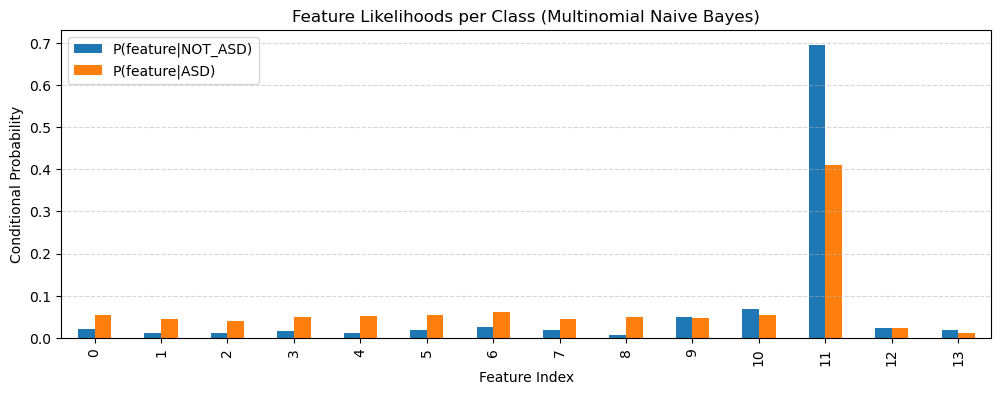

In [19]:

# --- Step 1: Extract log-probabilities learned by the Naive Bayes model ---
# 'feature_log_prob_' gives log P(feature|class)
feature_importance = np.exp(NaiveBayesModel.feature_log_prob_)  # convert log-probs to actual probabilities

# --- Step 2: Store as a DataFrame for easy viewing ---
importance_df = pd.DataFrame(
    feature_importance.T,                    # transpose so rows = features, columns = classes
    columns=['P(feature|NOT_ASD)', 'P(feature|ASD)']
)

# --- Step 3: Plot a bar chart comparing both classes for each feature ---
importance_df.plot.bar(figsize=(12,4))
plt.title("Feature Likelihoods per Class (Multinomial Naive Bayes)")  # descriptive title
plt.xlabel("Feature Index")                                          # x-axis label
plt.ylabel("Conditional Probability")                                # y-axis label
plt.grid(axis='y', linestyle='--', alpha=0.5)                        # horizontal grid
plt.show()

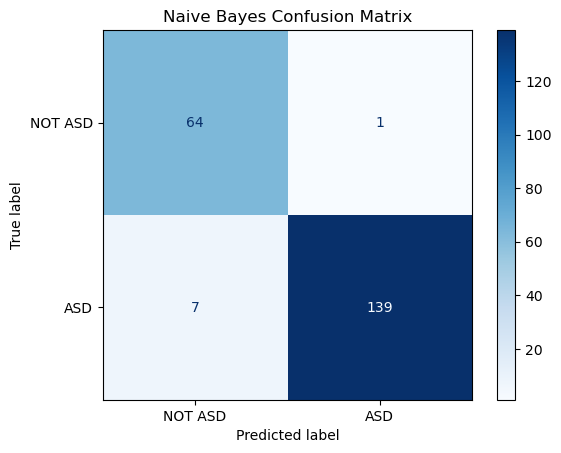

In [20]:
# --- Import from sklearn ---
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# --- Step 1: Compute confusion matrix ---
cm = confusion_matrix(y_test, y_predict)      # 2x2 matrix: [[TN, FP], [FN, TP]]

# --- Step 2: Plot confusion matrix nicely ---
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,                      # provide computed matrix
    display_labels=['NOT ASD', 'ASD']         # class labels
)
disp.plot(cmap='Blues', values_format='d')    # use blue colormap, integer counts
plt.title("Naive Bayes Confusion Matrix")     # add a title
plt.show()                                   # render plot

# 6. [Optional] Workshop


[Optionally] compare the performance of NB with previous model we have learnt (e.g. Decision Tree, KNN) and write down what you finding in the comparison, e.g. which model’s performance is better?



---
`The end is also called the new start.` ISS : **I** **S**(elf) **S**(tudy)

---